# Lasso regression

### The penalty that deletes features instead of shrinking them

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Why swapping a square for an absolute value produces exact zeros, what that geometry looks like, how Lasso behaves when features are correlated, and when to prefer it over Ridge |
| **You should already know** | [Ridge regression](../04-ridge-regression/) |
| **Datasets** | California Housing, with noise columns added to test feature selection |
| **Runtime** | About a minute on a laptop CPU |
| **Next** | [02-06 Elastic Net](../06-elastic-net/) |

---

## 1. One character of difference

[Ridge](../04-ridge-regression/) penalises the **square** of each weight. Lasso
penalises the **absolute value**:

$$J_{\text{ridge}} = \|Xw - y\|^2 + \alpha \sum_i w_i^2 \qquad\qquad J_{\text{lasso}} = \|Xw - y\|^2 + \alpha \sum_i |w_i|$$

That looks like a detail. It changes what the model does entirely: **Lasso sets
weights to exactly zero, and Ridge never does.**

The reason is the shape of the derivative. Near zero, the square's gradient is
$2w$, which vanishes as $w$ does — so the push toward zero weakens exactly when
it would be needed to finish the job, and the weight glides in without ever
arriving. The absolute value's gradient is $\pm\alpha$, constant all the way
down. It keeps pushing at full strength until the weight hits zero and stops.

Shrinkage versus selection, from one exponent.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

## 2. The geometry

The classic picture, and it is genuinely explanatory. Minimising squared error
subject to a budget on the weights means finding where the error contours first
touch the budget region. Ridge's budget region is a **circle**; Lasso's is a
**diamond** with corners on the axes.

A curve touching a circle almost never touches at exactly the top or side. A
curve touching a diamond very often touches at a corner — and a corner is a point
where one coordinate is exactly zero.

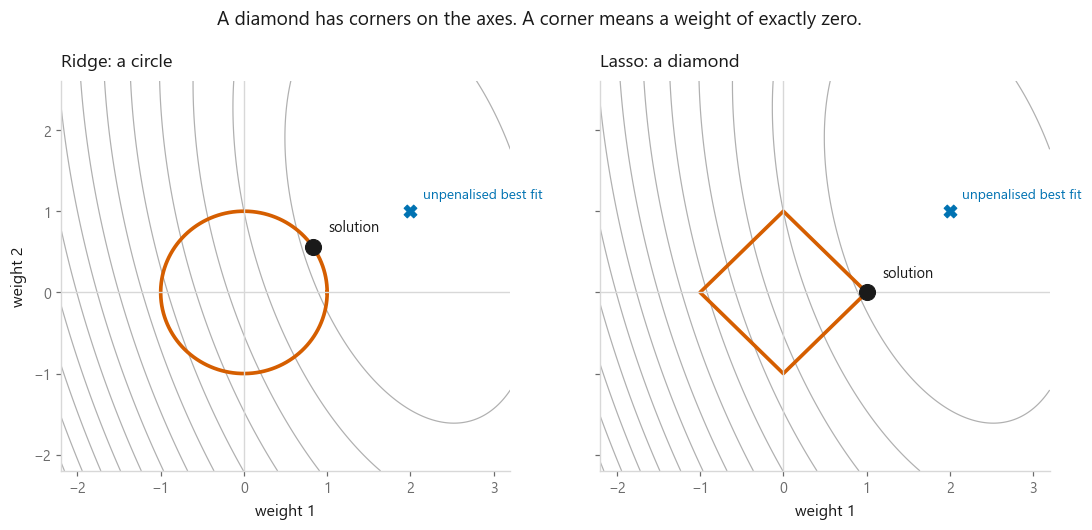

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.6), sharey=True)

grid = np.linspace(-2.2, 3.2, 400)
xx, yy = np.meshgrid(grid, grid)
centre = np.array([2.0, 1.0])
# Elongated error contours, as correlated features produce.
error = 3 * (xx - centre[0]) ** 2 + 1.2 * (xx - centre[0]) * (yy - centre[1]) + (yy - centre[1]) ** 2

for ax, (name, budget) in zip(axes, [("Ridge: a circle", "l2"), ("Lasso: a diamond", "l1")]):
    ax.contour(xx, yy, error, levels=14, colors=[style.NEUTRAL], linewidths=0.8)
    theta = np.linspace(0, 2 * np.pi, 400)
    if budget == "l2":
        radius = 1.0
        ax.plot(radius * np.cos(theta), radius * np.sin(theta), color=style.HIGHLIGHT, lw=2.4)
        touch = np.array([0.83, 0.56])
    else:
        radius = 1.0
        ax.plot([radius, 0, -radius, 0, radius], [0, radius, 0, -radius, 0],
                color=style.HIGHLIGHT, lw=2.4)
        touch = np.array([1.0, 0.0])
    ax.scatter(*touch, s=110, c=style.INK, zorder=5)
    ax.annotate("solution", xy=touch, xytext=(10, 10), textcoords="offset points",
                fontsize=9.5, color=style.INK)
    ax.scatter(*centre, s=70, c=style.PALETTE[0], marker="X", zorder=5)
    ax.annotate("unpenalised best fit", xy=centre, xytext=(8, 8), textcoords="offset points",
                fontsize=9, color=style.PALETTE[0])
    ax.axhline(0, color=style.RULE, lw=0.9)
    ax.axvline(0, color=style.RULE, lw=0.9)
    ax.set_xlim(-2.2, 3.2); ax.set_ylim(-2.2, 2.6)
    ax.set_xlabel("weight 1")
    ax.grid(False)
    style.title(ax, name)

axes[0].set_ylabel("weight 2")
fig.suptitle("A diamond has corners on the axes. A corner means a weight of exactly zero.",
             x=0.5, y=1.02, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-01-geometry.png")

## 3. The paths, side by side

The same sweep as the Ridge notebook, run for both penalties.

lasso alpha=0.001 : 8 features kept -> MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude
lasso alpha=0.05  : 4 features kept -> MedInc, HouseAge, Latitude, Longitude
lasso alpha=0.3   : 1 features kept -> MedInc


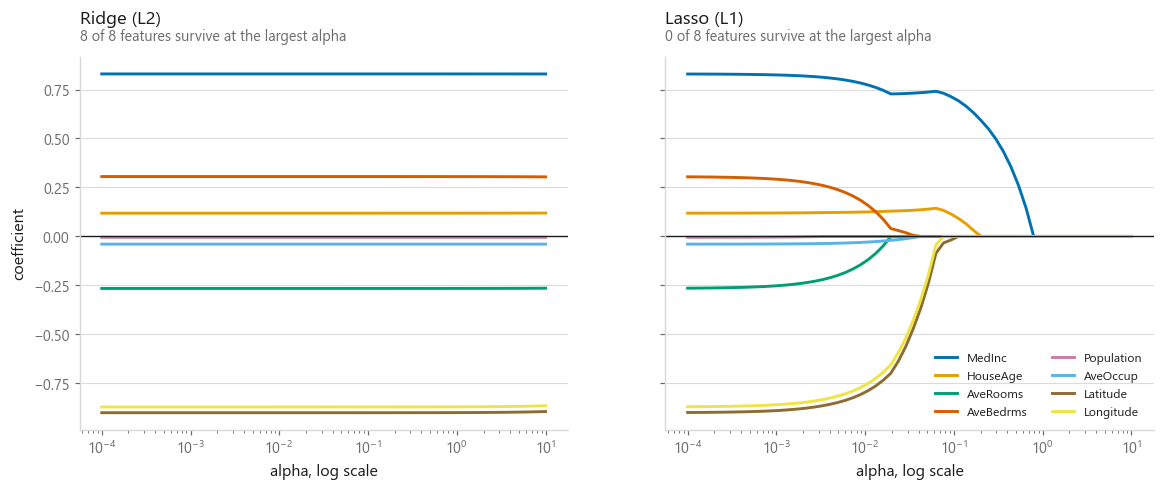

In [3]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import StandardScaler

X, y = datasets.california_housing()
X_scaled = StandardScaler().fit_transform(X)

alphas = np.logspace(-4, 1, 60)
ridge_paths = np.array([Ridge(alpha=a).fit(X_scaled, y).coef_ for a in alphas])
lasso_paths = np.array([Lasso(alpha=a, max_iter=20000).fit(X_scaled, y).coef_ for a in alphas])

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4), sharey=True)
for ax, paths, name in [(axes[0], ridge_paths, "Ridge (L2)"), (axes[1], lasso_paths, "Lasso (L1)")]:
    for i, column in enumerate(X.columns):
        ax.plot(alphas, paths[:, i], color=style.PALETTE[i % len(style.PALETTE)], label=column)
    ax.set_xscale("log")
    ax.axhline(0, color=style.INK, lw=0.9)
    ax.set_xlabel("alpha, log scale")
    nonzero = (np.abs(paths[-1]) > 1e-8).sum()
    style.title(ax, name, f"{nonzero} of {X.shape[1]} features survive at the largest alpha")

axes[0].set_ylabel("coefficient")
axes[1].legend(fontsize=8, ncols=2)
style.save(fig, FIG / "fig-02-paths.png")

for a in [0.001, 0.05, 0.3]:
    coefficients = Lasso(alpha=a, max_iter=20000).fit(X_scaled, y).coef_
    kept = [c for c, w in zip(X.columns, coefficients) if abs(w) > 1e-8]
    print(f"lasso alpha={a:<6}: {len(kept)} features kept -> {', '.join(kept)}")

Ridge's lines all glide toward zero and none arrive. Lasso's hit zero one by one
and stay there. Read right to left, the Lasso path is a ranking: the last feature
standing is the one the model considers most useful.

## 4. Does it find planted noise?

The honest test of a feature selector. Add columns that are pure random noise and
see whether Lasso removes them.

alpha chosen by cross-validation : 0.00321
real features kept  : 8 of 8
noise features kept : 17 of 30


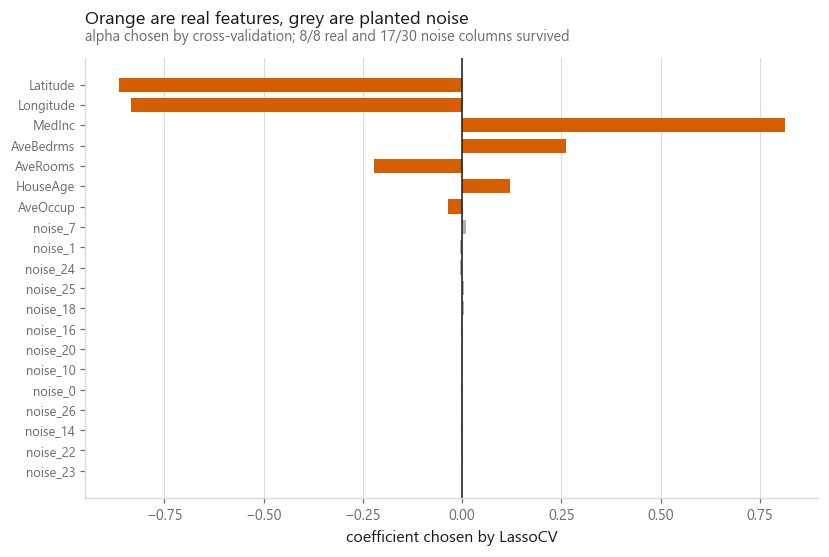

In [4]:
from sklearn.linear_model import LassoCV
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline

rng = np.random.default_rng(SEED)
N_NOISE = 30
noise = rng.normal(size=(len(X), N_NOISE))
X_padded = np.hstack([X.values, noise])
names = list(X.columns) + [f"noise_{i}" for i in range(N_NOISE)]

folds = KFold(5, shuffle=True, random_state=SEED)
selector = make_pipeline(StandardScaler(), LassoCV(cv=5, max_iter=20000, random_state=SEED))
selector.fit(X_padded, y)
chosen = selector.named_steps["lassocv"].coef_

real_kept = sum(1 for i in range(X.shape[1]) if abs(chosen[i]) > 1e-8)
noise_kept = sum(1 for i in range(X.shape[1], len(names)) if abs(chosen[i]) > 1e-8)

fig, ax = plt.subplots(figsize=(8.6, 5.2))
order = np.argsort(np.abs(chosen))[::-1][:20]
colours = [style.HIGHLIGHT if i < X.shape[1] else style.NEUTRAL for i in order]
ax.barh(range(len(order)), chosen[order][::-1], color=colours[::-1], height=0.7)
ax.set_yticks(range(len(order)), [names[i] for i in order][::-1], fontsize=8.5)
ax.axvline(0, color=style.INK, lw=1)
ax.set_xlabel("coefficient chosen by LassoCV")
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
style.title(ax, "Orange are real features, grey are planted noise",
            f"alpha chosen by cross-validation; {real_kept}/{X.shape[1]} real and "
            f"{noise_kept}/{N_NOISE} noise columns survived")
style.save(fig, FIG / "fig-03-feature-selection.png")

print(f"alpha chosen by cross-validation : {selector.named_steps['lassocv'].alpha_:.5f}")
print(f"real features kept  : {real_kept} of {X.shape[1]}")
print(f"noise features kept : {noise_kept} of {N_NOISE}")

**That is not the result the textbook promises, and it is the most useful thing
in this notebook.**

`LassoCV` kept every real feature — good — and also kept **17 of the 30 pure
noise columns**. Better than half the garbage survived a method sold as automatic
feature selection.

The reason is a mismatch of objectives that nobody mentions. Cross-validation
chose `alpha` to **minimise prediction error**, and it landed on 0.0032, which is
tiny. At that setting the penalty barely bites, so useless columns get small
non-zero weights rather than exact zeros. Those small weights cost almost nothing
in error — which is precisely why cross-validation is indifferent to them.

**Selecting features and predicting well are different goals, and `LassoCV`
optimises the second one.** If you want a short, defensible feature list, you
have to ask for it explicitly.

In [5]:
print(f"{'alpha':>8} {'real kept':>10} {'noise kept':>11} {'CV RMSE':>9}")
for a in [0.0032, 0.01, 0.03, 0.06, 0.1, 0.2]:
    model = make_pipeline(StandardScaler(), Lasso(alpha=a, max_iter=20000))
    coefficients = model.fit(X_padded, y).named_steps["lasso"].coef_
    real = sum(1 for i in range(X.shape[1]) if abs(coefficients[i]) > 1e-8)
    junk = sum(1 for i in range(X.shape[1], len(names)) if abs(coefficients[i]) > 1e-8)
    score = -cross_val_score(model, X_padded, y, cv=folds,
                             scoring="neg_root_mean_squared_error", n_jobs=-1).mean()
    print(f"{a:>8} {real:>7}/{X.shape[1]} {junk:>8}/{N_NOISE} {score:>9.4f}")

   alpha  real kept  noise kept   CV RMSE


  0.0032       8/8       17/30    0.7267


    0.01       7/8        1/30    0.7291


    0.03       6/8        0/30    0.7497


    0.06       4/8        0/30    0.7982


     0.1       3/8        0/30    0.8211


     0.2       1/8        0/30    0.8609


Raising `alpha` cleans the list out, and the prediction error barely moves until
it starts discarding real features too. That table is the actual decision: pick
`alpha` by cross-validation if you want the best prediction, or pick it further
along the path if you want a shortlist you can defend — and know which one you
are doing.

## 5. Where Lasso struggles

Correlated features are Lasso's known weakness, and it is worth seeing rather
than reading. Given several features carrying the same information, Lasso tends
to keep **one arbitrarily** and zero the rest — where Ridge splits the weight
between them.

That is fine if you only want predictions. It is misleading if you then say "the
model selected this feature, so it is the important one", because a reshuffle of
the data can select a different member of the group.

standard deviation of each twin's coefficient across 12 bootstrap refits:
  lasso : 0.360  0.257  0.191
  ridge : 0.113  0.113  0.128


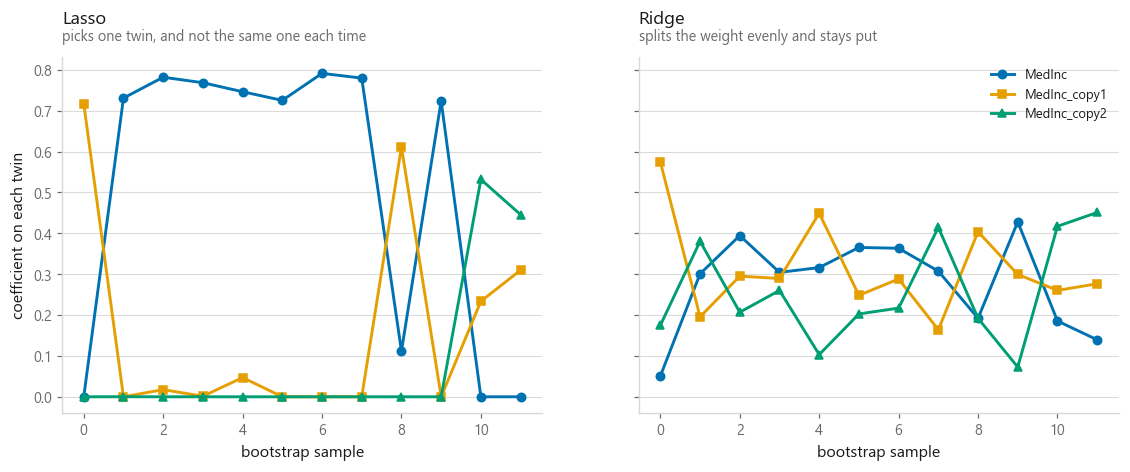

In [6]:
X_twins = X.copy()
X_twins["MedInc_copy1"] = X["MedInc"] + rng.normal(0, 0.01, len(X))
X_twins["MedInc_copy2"] = X["MedInc"] + rng.normal(0, 0.01, len(X))
twin_columns = ["MedInc", "MedInc_copy1", "MedInc_copy2"]

records = []
for trial in range(12):
    sample = rng.choice(len(X_twins), 4000, replace=True)
    scaled = StandardScaler().fit_transform(X_twins.values[sample])
    lasso = Lasso(alpha=0.02, max_iter=20000).fit(scaled, y.values[sample])
    ridge = Ridge(alpha=1.0).fit(scaled, y.values[sample])
    positions = [list(X_twins.columns).index(c) for c in twin_columns]
    records.append({"trial": trial,
                    **{f"lasso {c}": lasso.coef_[p] for c, p in zip(twin_columns, positions)},
                    **{f"ridge {c}": ridge.coef_[p] for c, p in zip(twin_columns, positions)}})
twins = pd.DataFrame(records)

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.2), sharey=True)
for ax, method in zip(axes, ["lasso", "ridge"]):
    for i, c in enumerate(twin_columns):
        ax.plot(twins["trial"], twins[f"{method} {c}"], marker=style.MARKERS[i],
                color=style.PALETTE[i], label=c)
    ax.set_xlabel("bootstrap sample")
    style.title(ax, method.capitalize(),
                "picks one twin, and not the same one each time" if method == "lasso"
                else "splits the weight evenly and stays put")
axes[0].set_ylabel("coefficient on each twin")
axes[1].legend(fontsize=8.5)
style.save(fig, FIG / "fig-04-correlated-features.png")

print("standard deviation of each twin's coefficient across 12 bootstrap refits:")
for method in ["lasso", "ridge"]:
    spreads = [twins[f"{method} {c}"].std() for c in twin_columns]
    print(f"  {method:<6}: " + "  ".join(f"{s:.3f}" for s in spreads))

Lasso's choice among the twins jumps from sample to sample. Ridge's does not.

When you have correlated groups and want both selection *and* stability, the
answer is [Elastic Net](../06-elastic-net/), which mixes both penalties and keeps
or drops correlated features together.

### And the accuracy?

In [7]:
from sklearn.linear_model import LinearRegression

print("cross-validated RMSE on California Housing with 30 noise columns added")
for name, model in [
    ("ordinary least squares", make_pipeline(StandardScaler(), LinearRegression())),
    ("ridge, alpha=1", make_pipeline(StandardScaler(), Ridge(alpha=1.0))),
    ("lasso, alpha chosen by CV", make_pipeline(StandardScaler(), LassoCV(cv=5, max_iter=20000, random_state=SEED))),
]:
    score = -cross_val_score(model, X_padded, y, cv=folds,
                             scoring="neg_root_mean_squared_error", n_jobs=-1).mean()
    print(f"  {name:<28}: {score:.4f}")

cross-validated RMSE on California Housing with 30 noise columns added


  ordinary least squares      : 0.7271


  ridge, alpha=1              : 0.7271


  lasso, alpha chosen by CV   : 0.7270


## Cheat sheet

| | |
|---|---|
| **Use it when** | You have many features and suspect most are useless; you want a smaller model; you need a defensible feature shortlist |
| **Prefer Ridge when** | Features are correlated and you want stable coefficients; you believe every feature contributes a little |
| **Prefer Elastic Net when** | Both: correlated groups **and** you want selection |
| **Scaling needed** | Yes, always. The penalty is unit-blind |
| **Main dial** | `alpha`. `LassoCV` chooses it by cross-validation along the whole path efficiently |
| **No closed form** | Unlike Ridge. The absolute value is not differentiable at zero, so it is solved by coordinate descent — hence `max_iter` |
| **Watch out** | Among correlated features it picks one nearly at random. Do not read that as importance |
| **Watch out more** | `LassoCV` tunes for prediction, not sparsity. It kept 17 of 30 noise columns here. For a shortlist, choose `alpha` yourself |

## What to remember

1. Ridge penalises $w^2$, Lasso penalises $|w|$. That single change turns
   shrinkage into selection.
2. It works because the absolute value's gradient stays constant all the way to
   zero, while the square's fades out.
3. The constraint region is a diamond, and its corners sit on the axes.
4. **`LassoCV` is not a feature selector.** Given 30 planted noise columns it
   kept 17 of them, because cross-validation optimises prediction error and a
   useless column with a tiny weight barely costs any. Raise `alpha` past the
   cross-validated optimum if you actually want a shortlist.
5. Among correlated twins it keeps one arbitrarily, and the choice moves from
   sample to sample. Ridge's does not.
6. No closed form — it iterates, so raise `max_iter` if it warns.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [02-06 Elastic Net](../06-elastic-net/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#Lasso` `#L1Regularization` `#FeatureSelection` `#Regression`
`#Python` `#ScikitLearn` `#DataScience` `#MLTutorial` `#SparseModels`